# How to use the dataset: shuffled dataset
In this notebook, we show examples of usage for the dataset
- We use Isolation Forest with a shuffled dataset to perform a classification of normal/attack instances.
- We perform the same classification using XGBoost.

### Import the dataset

In [1]:
from ast import literal_eval

import numpy as np
import pandas as pd

In [2]:

df = pd.read_csv("./Untitled Folder/ROSPaCe_complete_noperiodicity.csv")


/tmp/ipykernel_2527869/3222811869.py:1: DtypeWarning: Columns (16,20,21,28,30,31,32,33,34,35,45,55,59,62,65,66,70,73,80,87,96,98,100,105,108,109,121,125,126,129,131,133,135,139,140,141,144,145,146,149,150,151,152,153,154,157,158,165,167,168,169,170,171,172,174,177,181,182,186,187,191,192,194,199,200,201,202,206,209,213,214,215,216,217,218,221,223,225,228,232,234,237,241,242,249,251,252,253,254,255,256,261,264,265,276,280,281,284,286,288,290,294,295,299,300,304,305,309,315,323,329,330,341,345,347,351,353,357,359,362,363,366,367,370,371,374,376,380,381,385,388,391,396,400,401,405,406,409,413,414,418,419,424,430,431,432,435,436,437,440,442,443,444,445,448,449,450,476,479,480) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./Untitled Folder/ROSPaCe_complete_noperiodicity.csv")


## Prepare the data for ML
In this section, we prepare the data to be processed by ML algorithms. In particular, we perform the following steps:
- <strong>Convert mixed dtypes </strong>: we uniform the type of features with mixed type values.
- <strong>Handle NaN values</strong>: we replace NaN and infinite values with -1. 
- <strong>Convert Label to Numeric</strong>: We substitute label values with numeric values. Then, we create two versions of the dataset: with  binary labels (attack, normal), and with multiple labels (one label for each attack).
- <strong>Convert String To Numeric</strong>: we convert the string values to numbers using categorical encoding. This technique assigns a unique number to any unique string values of a feature.
- <strong>Split the dataset in Training and Test sets</strong>: after removing labels and timestamps columns, we split the dataframe in training and test sets with a 60/40 split.

### Convert mixed DTypes

In [3]:

def convert_dtype(x):
    if not x:
        return ""
    try:
        return str(x)
    except:
        return ""


def convert_hex(x):
    if not x:
        return 0
    try:
        return literal_eval(x)
    except:
        return 0


In [4]:

# Indexes of the columns to be converted
to_convert = [12, 15, 20, 25, 29, 56, 59, 60]


In [5]:

# Convert
for i in to_convert:
    df[df.columns[i]] = df[df.columns[i]].apply(lambda x: convert_dtype(x))


### Handle NaN values

In [6]:

nanv = []
for col in df.columns:
    nanv.append(df[col].isnull().values.any())


In [7]:

print(nanv)


[False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, True, True, True, True, False, True, True, True, True, False, True, True, True, False, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, False, True, True, False, False, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, 

In [8]:

df.replace([np.inf, -np.inf], -1, inplace=True)
df.fillna(-1, inplace=True)
df = df.dropna(thresh=1, axis=1)


In [9]:

df.replace("nan", -1, inplace=True)


In [10]:

nanv = []
for col in df.columns:
    nanv.append(df[col].isnull().values.any())
print(nanv)


[False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False

In [11]:

# Save the processed dataset
df.to_csv("./Untitled Folder/reduced_final_nan.csv")
# df = pd.read_csv('/data/puccetti/space_data/final_full_dataset_nan.csv')


### Convert Label columns to Numeric values
We substitute label values with numeric values. We create two version of the dataset:
- binary classification
- multiple label classification

In [12]:

print(df["attack"].value_counts())


attack
metasploit SYN flood    9236810
nmap SYN flood          5392828
observe                 5330564
nmap discovery           540042
ros2 reconnaissance      341312
ros2 node crashing         5742
ros2 reflection            3753
Name: count, dtype: int64


In [13]:

print(df.columns)


Index(['timestamp', 'layers.frame.frame.time', 'layers.frame.frame.time_delta',
       'layers.frame.frame.time_delta_displayed',
       'layers.frame.frame.time_relative', 'layers.frame.frame.number',
       'layers.frame.frame.len', 'layers.frame.frame.cap_len',
       'layers.frame.frame.protocols', 'layers.sll.sll.pkttype',
       ...
       'Active', 'pgalloc_dma', 'pgmajfault', 'SwapFree', 'src_topic',
       'subscribers_count', 'publishers_count', 'msg_type', 'msg_data',
       'attack'],
      dtype='object', length=482)


In [14]:

df["attack"] = df["attack"].replace("metasploit SYN flood", 1)
df["attack"] = df["attack"].replace("nmap discovery", 2)
df["attack"] = df["attack"].replace("nmap SYN flood", 3)
df["attack"] = df["attack"].replace("ros2 node crashing", 4)
df["attack"] = df["attack"].replace("ros2 reconnaissance", 5)
df["attack"] = df["attack"].replace("ros2 reflection", 6)
df["attack"] = df["attack"].replace("observe", 0)

df["attack"] = pd.to_numeric(df["attack"])

df["attack"].unique(), df["attack"].nunique()


/tmp/ipykernel_2527869/2301323652.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["attack"] = df["attack"].replace("observe", 0)


(array([0, 2, 5, 6, 4, 3, 1]), 7)

In [15]:

print(df["attack"].value_counts())


attack
1    9236810
3    5392828
0    5330564
2     540042
5     341312
4       5742
6       3753
Name: count, dtype: int64


### Convert String to Numeric

In [16]:

list_column_string = df.select_dtypes(exclude=[np.number])

for i in list_column_string:
    if i != "timestamp":
        df[i] = pd.Categorical(df[i])


In [17]:

for i in list_column_string:
    if i != "timestamp":
        df[i] = df[i].cat.codes


#### Create binary label and multiple labels dataset

In [18]:

df.to_csv("./Untitled Folder/usable_temp_multi.csv")


In [19]:

df["attack"] = df["attack"].replace(2, 1)
df["attack"] = df["attack"].replace(3, 1)
df["attack"] = df["attack"].replace(4, 1)
df["attack"] = df["attack"].replace(5, 1)
df["attack"] = df["attack"].replace(6, 1)


In [20]:

print(df["attack"].value_counts())


attack
1    15520487
0     5330564
Name: count, dtype: int64


In [21]:

df.to_csv("./Untitled Folder/usable_temp_bin.csv")


In [22]:
df = pd.read_csv("./Untitled Folder/usable_temp_bin.csv")

## Train / Test Split

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
subs = "Unnamed"
res = [i for i in df.columns if subs in i]
print(len(res))
print(res)
df = df.drop(res, axis=1)

1
['Unnamed: 0']


In [25]:
label = df["attack"]
df = df.drop(["attack"], axis=1)

In [26]:
x_train, x_test, y_train, y_test = train_test_split(
    df, label, test_size=0.4, random_state=42
)
 
x_train = x_train.select_dtypes(exclude=['object', 'datetime64']) #something new
x_test = x_test.select_dtypes(exclude=['object', 'datetime64']) #something new

x_train = x_train.to_numpy()
x_test = x_test.to_numpy()

In [27]:
print("Train Set Shape: " + str(x_train.shape))
print("Train Set Label Shape: " + str(y_train.shape))
print("Test Set Shape: " + str(x_test.shape))
print("Test Set Label Shape: " + str(y_test.shape))

Train Set Shape: (12510630, 480)
Train Set Label Shape: (12510630,)
Test Set Shape: (8340421, 480)
Test Set Label Shape: (8340421,)


## Binary classification with Isolation Forest 

In [28]:
import matplotlib.pyplot as plt
import sklearn
from sklearn.ensemble import IsolationForest as isol

In [29]:

contamination = 1 - (np.sum(y_train) / np.shape(y_train))
is_forsest = isol(n_estimators=300, contamination="auto")
# fit model
is_forsest.fit(x_train)

IsolationForest(n_estimators=300)

In [30]:

import joblib

# 設定你想要儲存的檔名
model_filename = './isolation_forest_model.joblib'

# 將訓練好的模型 (is_forsest) 存入檔案
joblib.dump(is_forsest, model_filename)

print(f"模型已成功儲存至: {model_filename}")


模型已成功儲存至: ./isolation_forest_model.joblib


In [31]:
# make predictions
iso_preds = is_forsest.predict(x_test)

In [32]:
iso_preds[iso_preds == 1] = 0
iso_preds[iso_preds == -1] = 1
contamination

array([0.25559344])

In [33]:
len(iso_preds)

8340421

### Compute Accuracy and ROC Curve

In [34]:
iso_preds = 1 - iso_preds
acc = sklearn.metrics.accuracy_score(y_test, iso_preds)
#y_test = np.where(y_test == -1, 1, y_test) #something new
tn, fp, fn, tp = sklearn.metrics.confusion_matrix(y_test, iso_preds).ravel()

In [35]:
np.save("./iso_predictions_shuffled.npy", iso_preds)
np.save("./y_test_iso.npy", y_test)

In [36]:

iso_preds = np.load("./iso_predictions_shuffled.npy")
y_test = np.load("./y_test_iso.npy")


In [37]:
print("accuracy " + str(acc))
print("TN {}, FP {}, FN {}, TP {} ".format(tn, fp, fn, tp))

accuracy 0.7864074247570956
TN 514905, FP 1618024, FN 163428, TP 6044064 


In [38]:
rec = sklearn.metrics.recall_score(y_test, iso_preds)
print(rec)

0.9736724590220978


In [39]:
prec = sklearn.metrics.precision_score(y_test, iso_preds)
print(prec)

0.7888272752805763


In [40]:
preds = is_forsest.decision_function(x_test)

In [41]:
def percent(num_a, num_b):
    return int((num_a / 100) * num_b)

In [42]:
fpr, tpr, _ = sklearn.metrics.roc_curve(y_test, preds)
fpr = np.asarray(fpr)
tpr = np.asarray(tpr)
print(fpr, tpr)

[0.         0.         0.         ... 0.99999906 0.99999906 1.        ] [0.00000000e+00 1.61095657e-07 7.73259152e-06 ... 9.99999839e-01
 1.00000000e+00 1.00000000e+00]


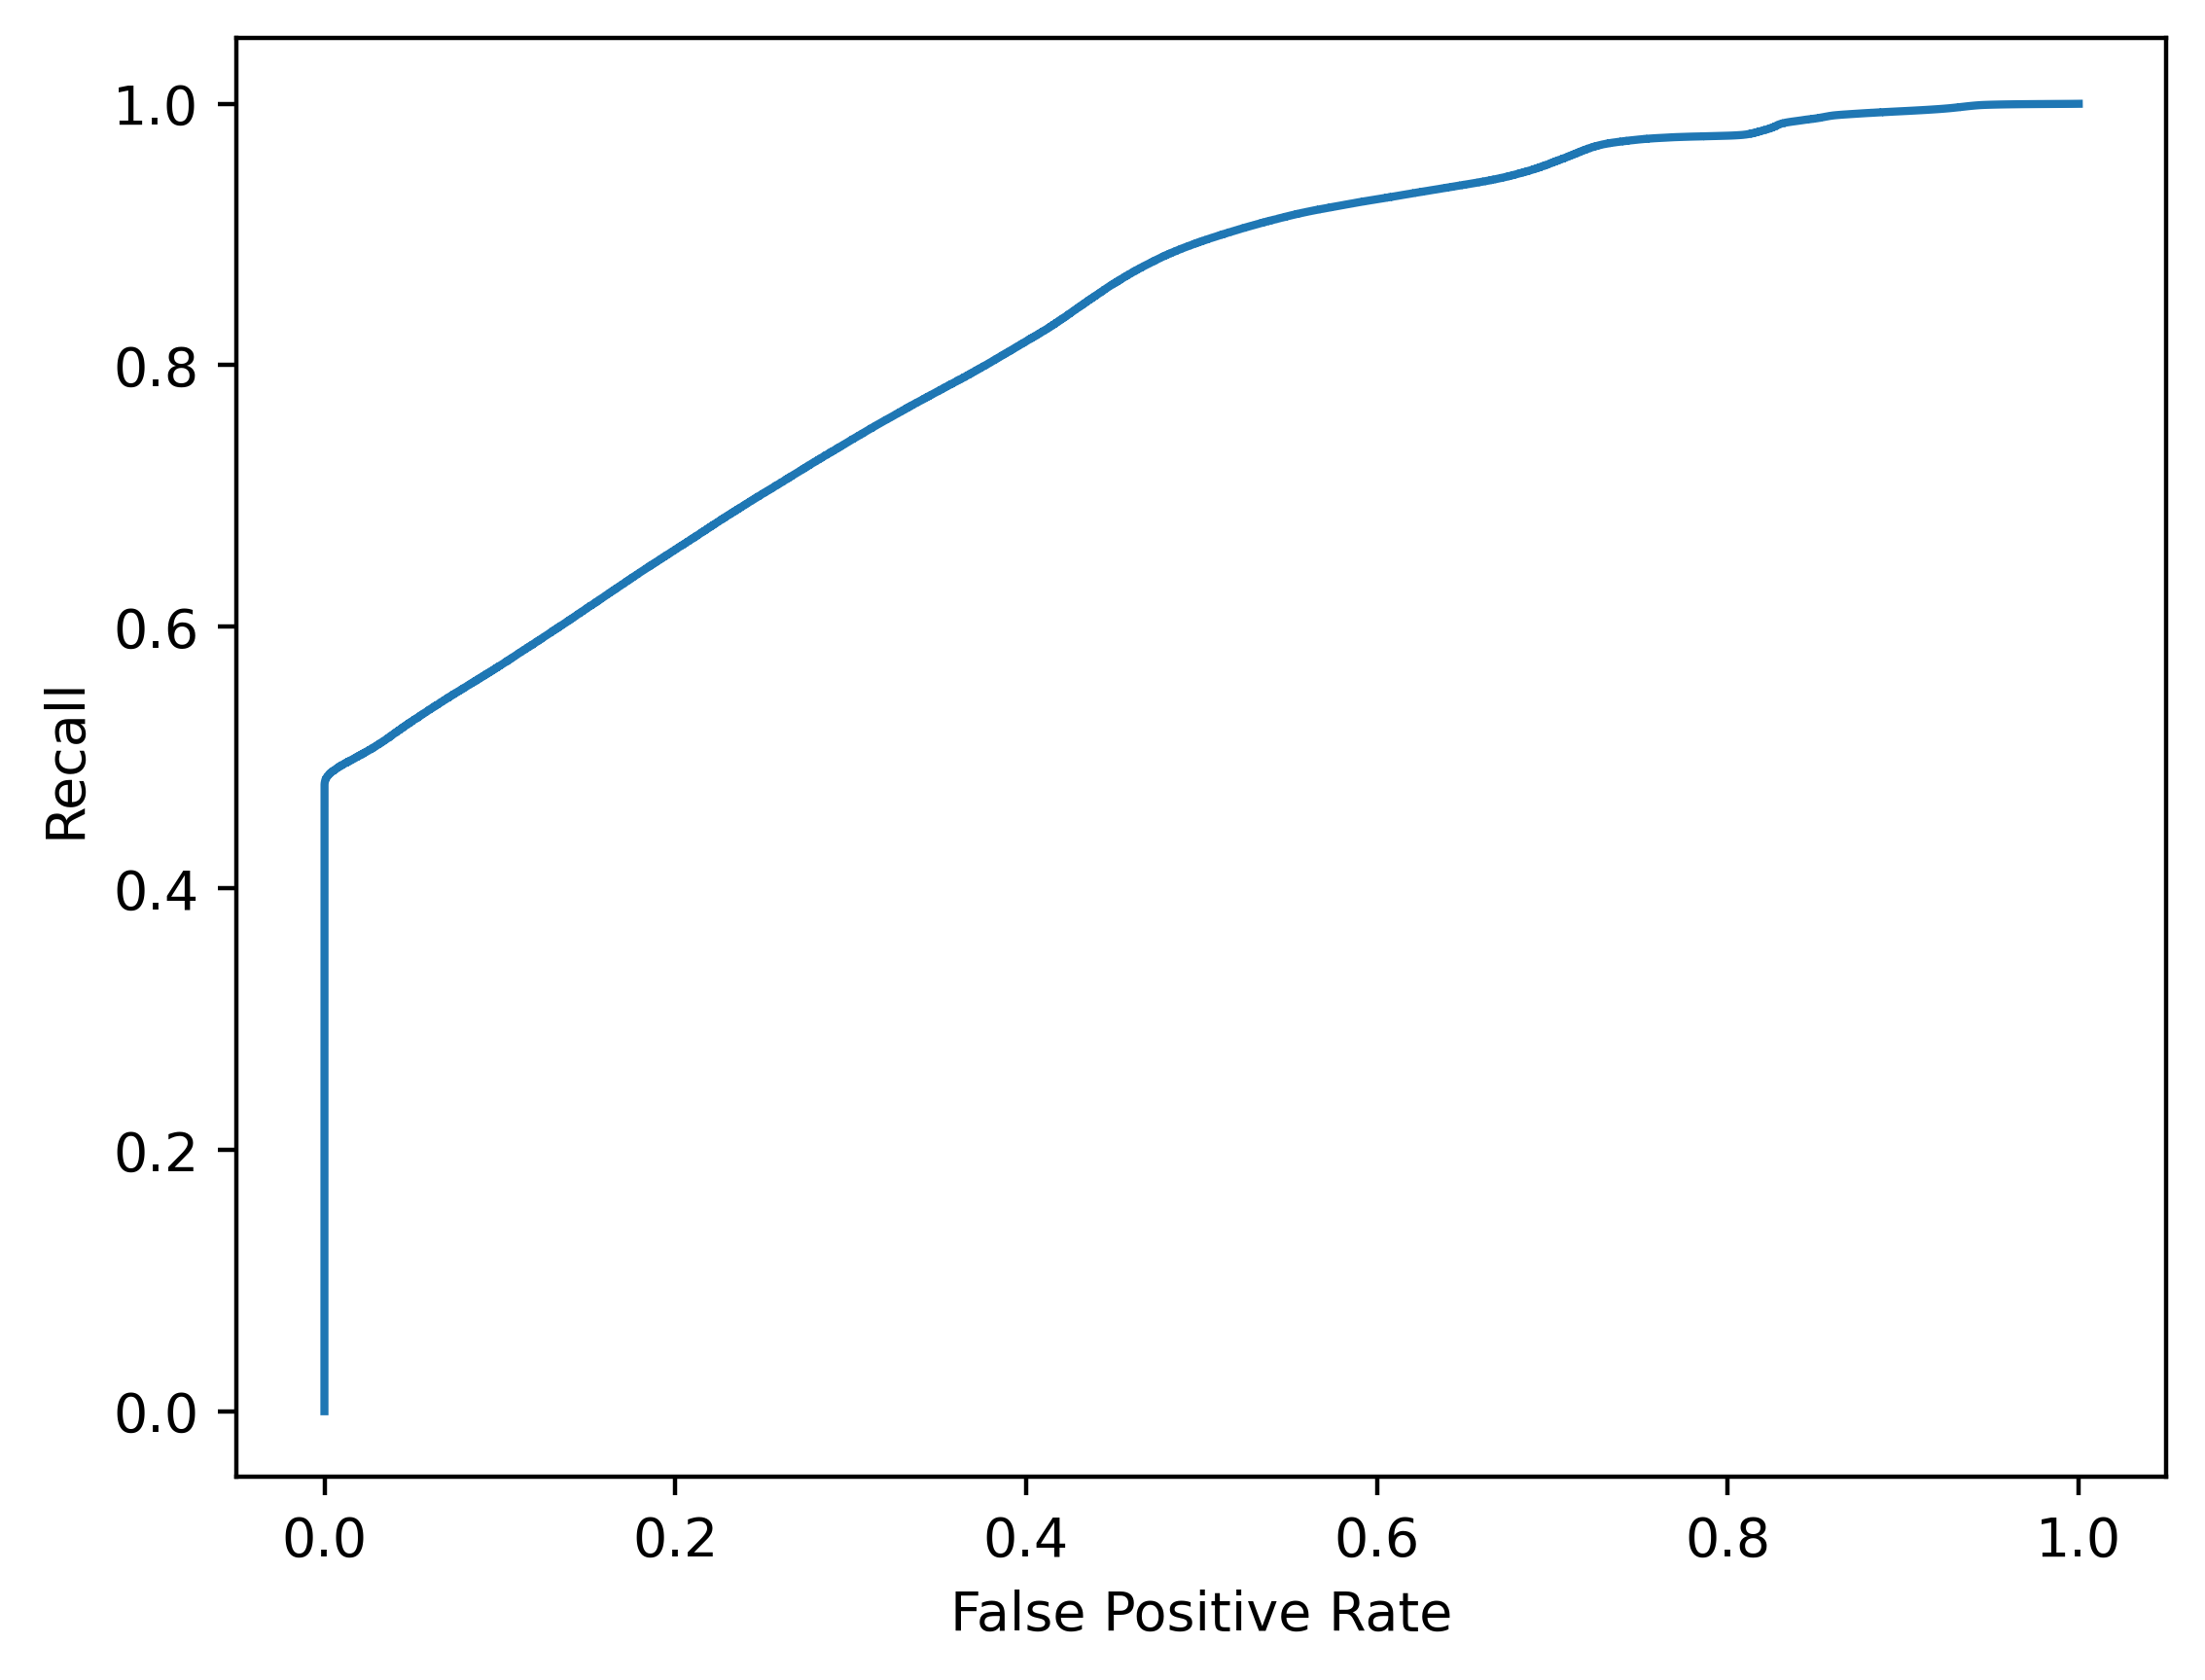

In [43]:
plt.figure(dpi=400)
plt.plot(fpr, tpr)
plt.ylabel("Recall")
plt.xlabel("False Positive Rate")
plt.show()

In [44]:
np.save("./fpr_iso.npy", fpr)
np.save("./tpr_iso.npy", tpr)

### Compute Precision-Recall Curve

In [45]:
precision, recall, thr = sklearn.metrics.precision_recall_curve(y_test, preds)

In [46]:
TARGET_TPR = 0.005
tpr_index = np.min(np.where(recall >= TARGET_TPR))
tpr_value = tpr[tpr_index]
fpr_index = np.min(np.where(recall >= TARGET_TPR))
fpr_value = fpr[tpr_index]
# p_value=p[tpr_index]
print("TPR {} , FPR {}".format(tpr_value, fpr_value))

TPR 0.0 , FPR 0.0


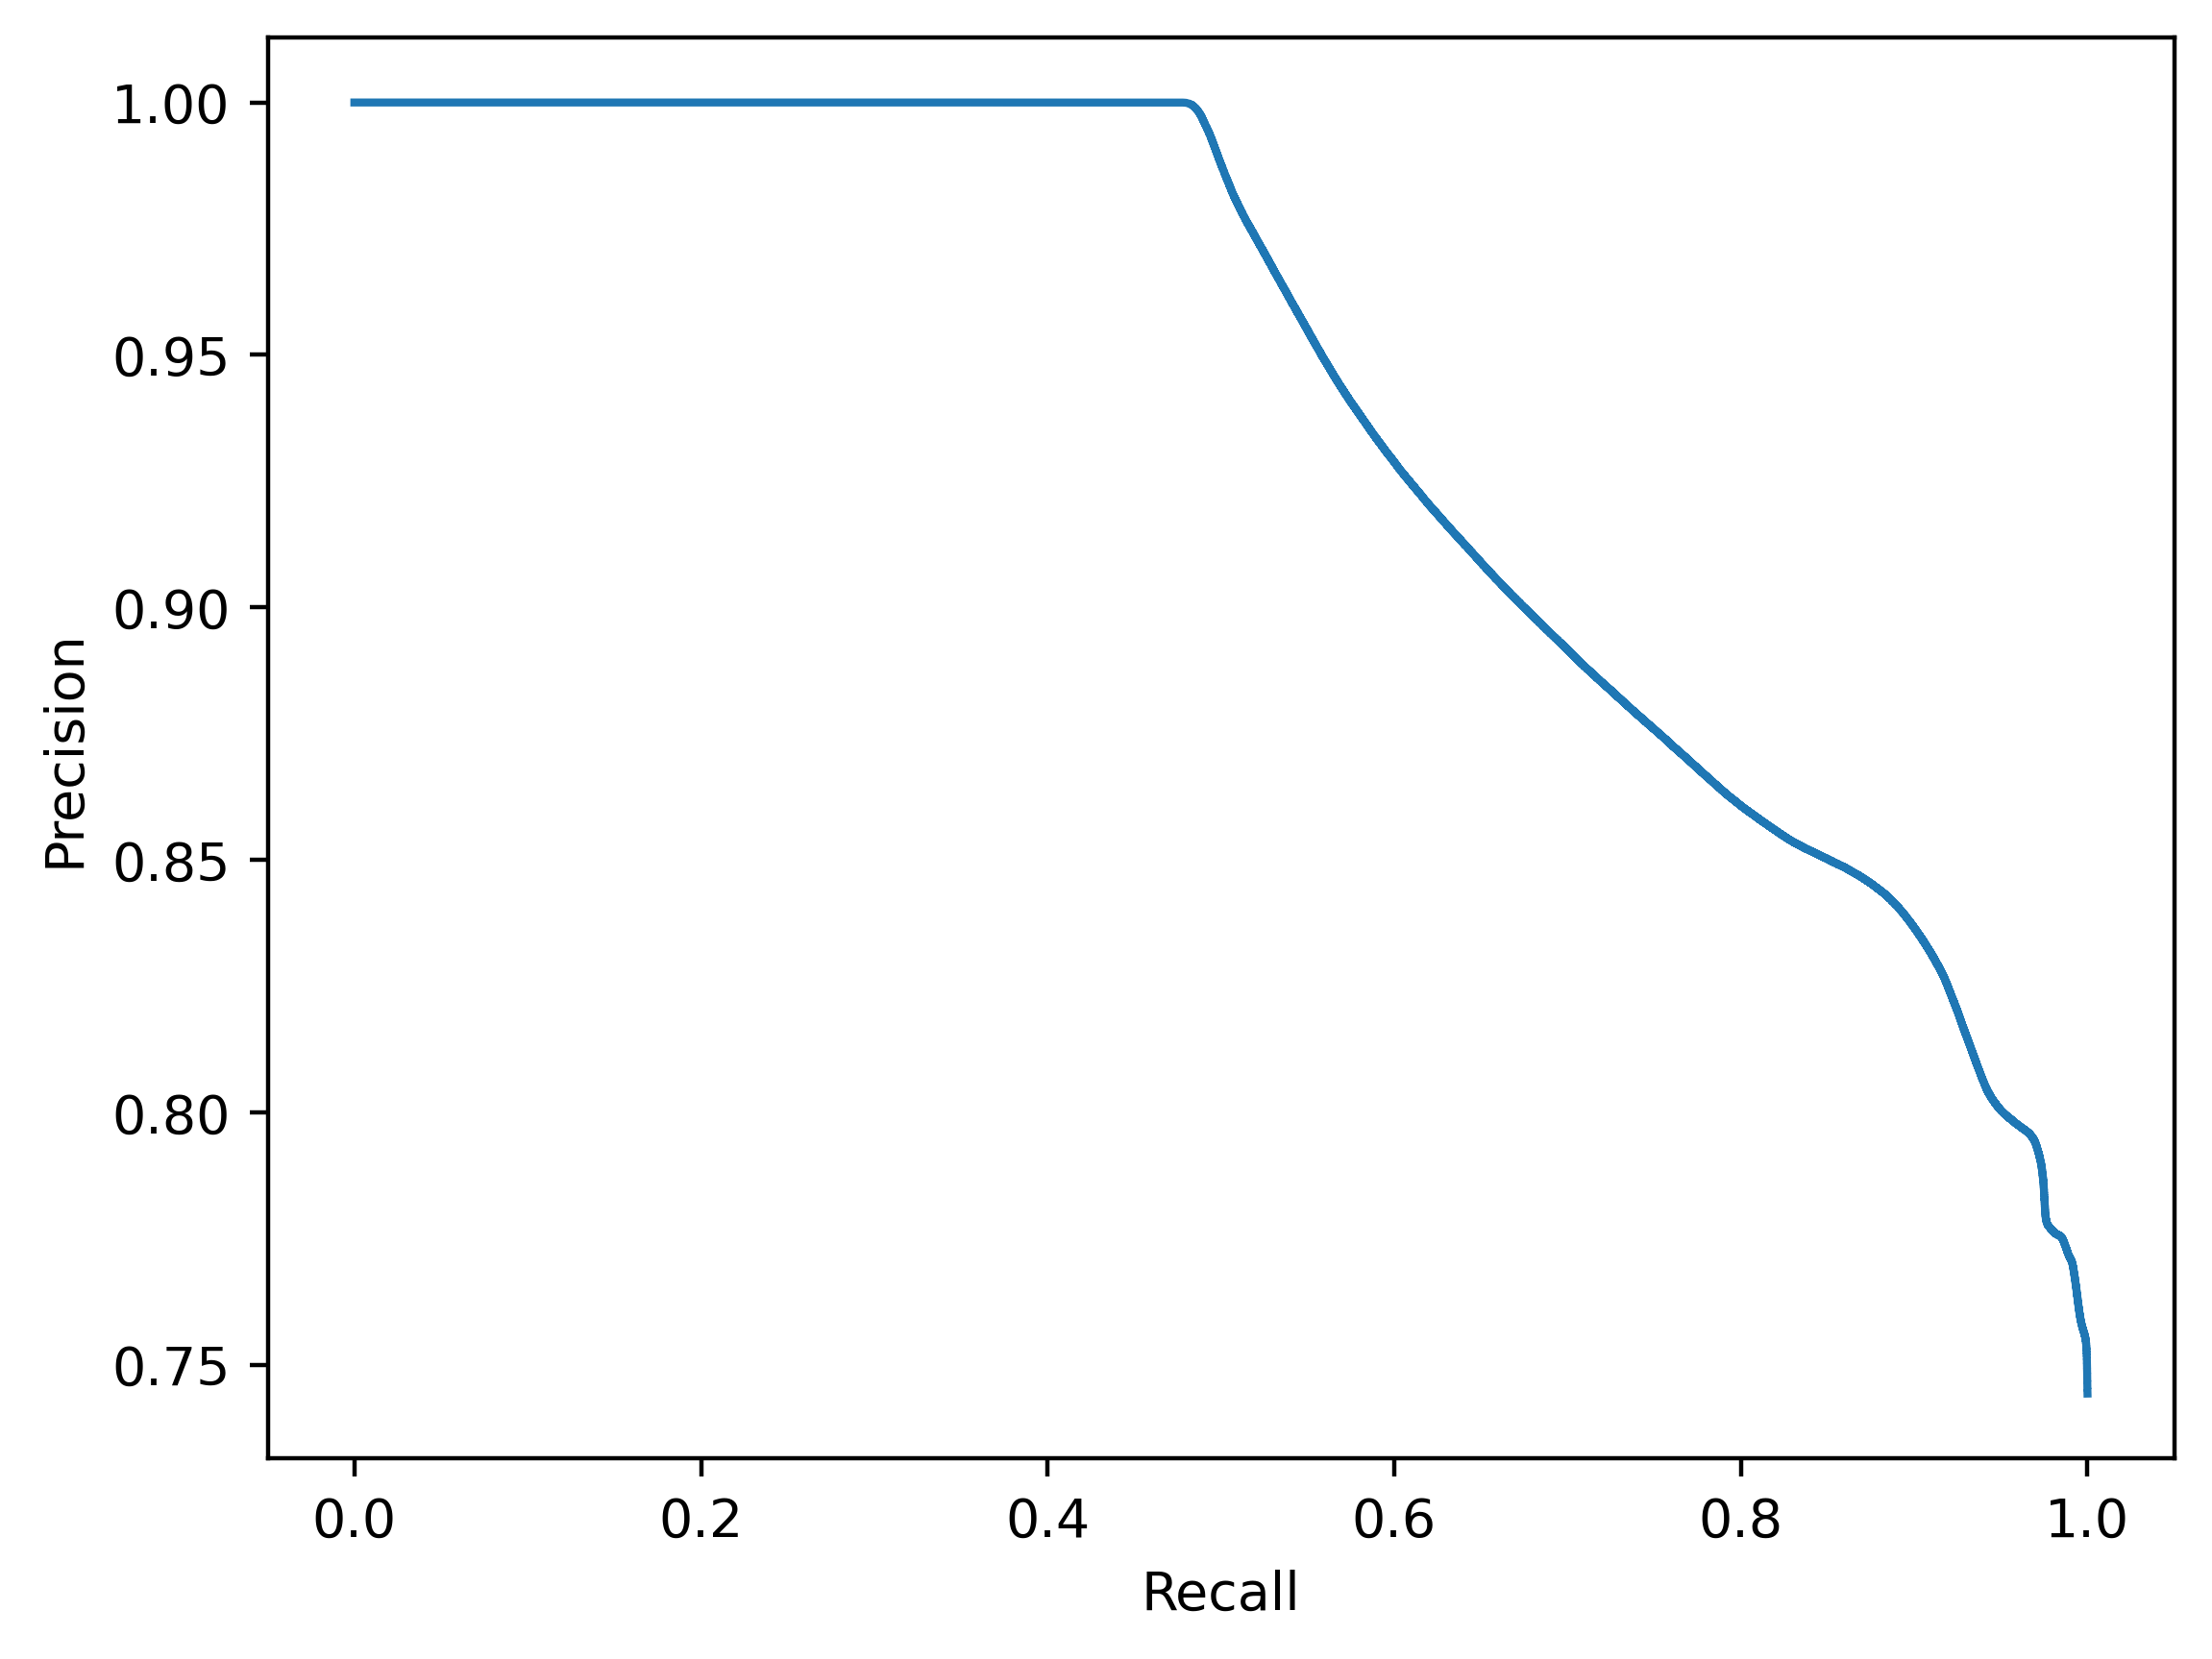

In [47]:
plt.figure(dpi=400)
plt.plot(recall, precision)
# plt.plot(recall[0:percent(len(recall), 100)], precision[0:percent(len(precision), 100)])
plt.ylabel("Precision")
plt.xlabel("Recall")
plt.show()

In [48]:
np.save("./recall_iso.npy", recall)
np.save("./precision_iso.npy", precision)

## Binary classification with XGBoost 

In [49]:

from xgboost import XGBClassifier


In [50]:

bst = XGBClassifier(
    n_estimators=10, max_depth=20, learning_rate=1.0, objective="binary:logistic"
)
# fit model
bst.fit(x_train, y_train)
# make predictions
xgb_preds = bst.predict(x_test)


In [51]:

np.save("./xgb_predictions_shuffled.npy", xgb_preds)


First, we compute the Confusion Matrix and the Accuracy

In [52]:

acc = sklearn.metrics.accuracy_score(y_test, xgb_preds)
tn, fp, fn, tp = sklearn.metrics.confusion_matrix(y_test, xgb_preds).ravel()


In [53]:

print("Accuracy " + str(acc))
print("TN {}, FP {}, FN {}, TP {} ".format(tn, fp, fn, tp))


Accuracy 0.9991458464746564
TN 2129624, FP 3305, FN 3819, TP 6203673 


In [54]:
 
rec = sklearn.metrics.recall_score(y_test, xgb_preds)
print(rec)


0.9993847756871858


In [55]:
 
prec = sklearn.metrics.precision_score(y_test, xgb_preds)
print(prec)


0.9994675347649049


We calculate the ROC curve

In [56]:
 
preds_proba = bst.predict_proba(x_test)


In [57]:
 
np.save("./xgb_predictions_proba_shuffled.npy", xgb_preds)
np.save("./y_test_xgb.npy", y_test)


In [58]:
 
import matplotlib.pyplot as plt
from sklearn import metrics


In [59]:
 
fpr, tpr, _ = metrics.roc_curve(y_test, preds_proba[:, 1])


In [60]:

fpr = np.asarray(fpr)
tpr = np.asarray(tpr)


In [61]:
 
len(tpr)


335155

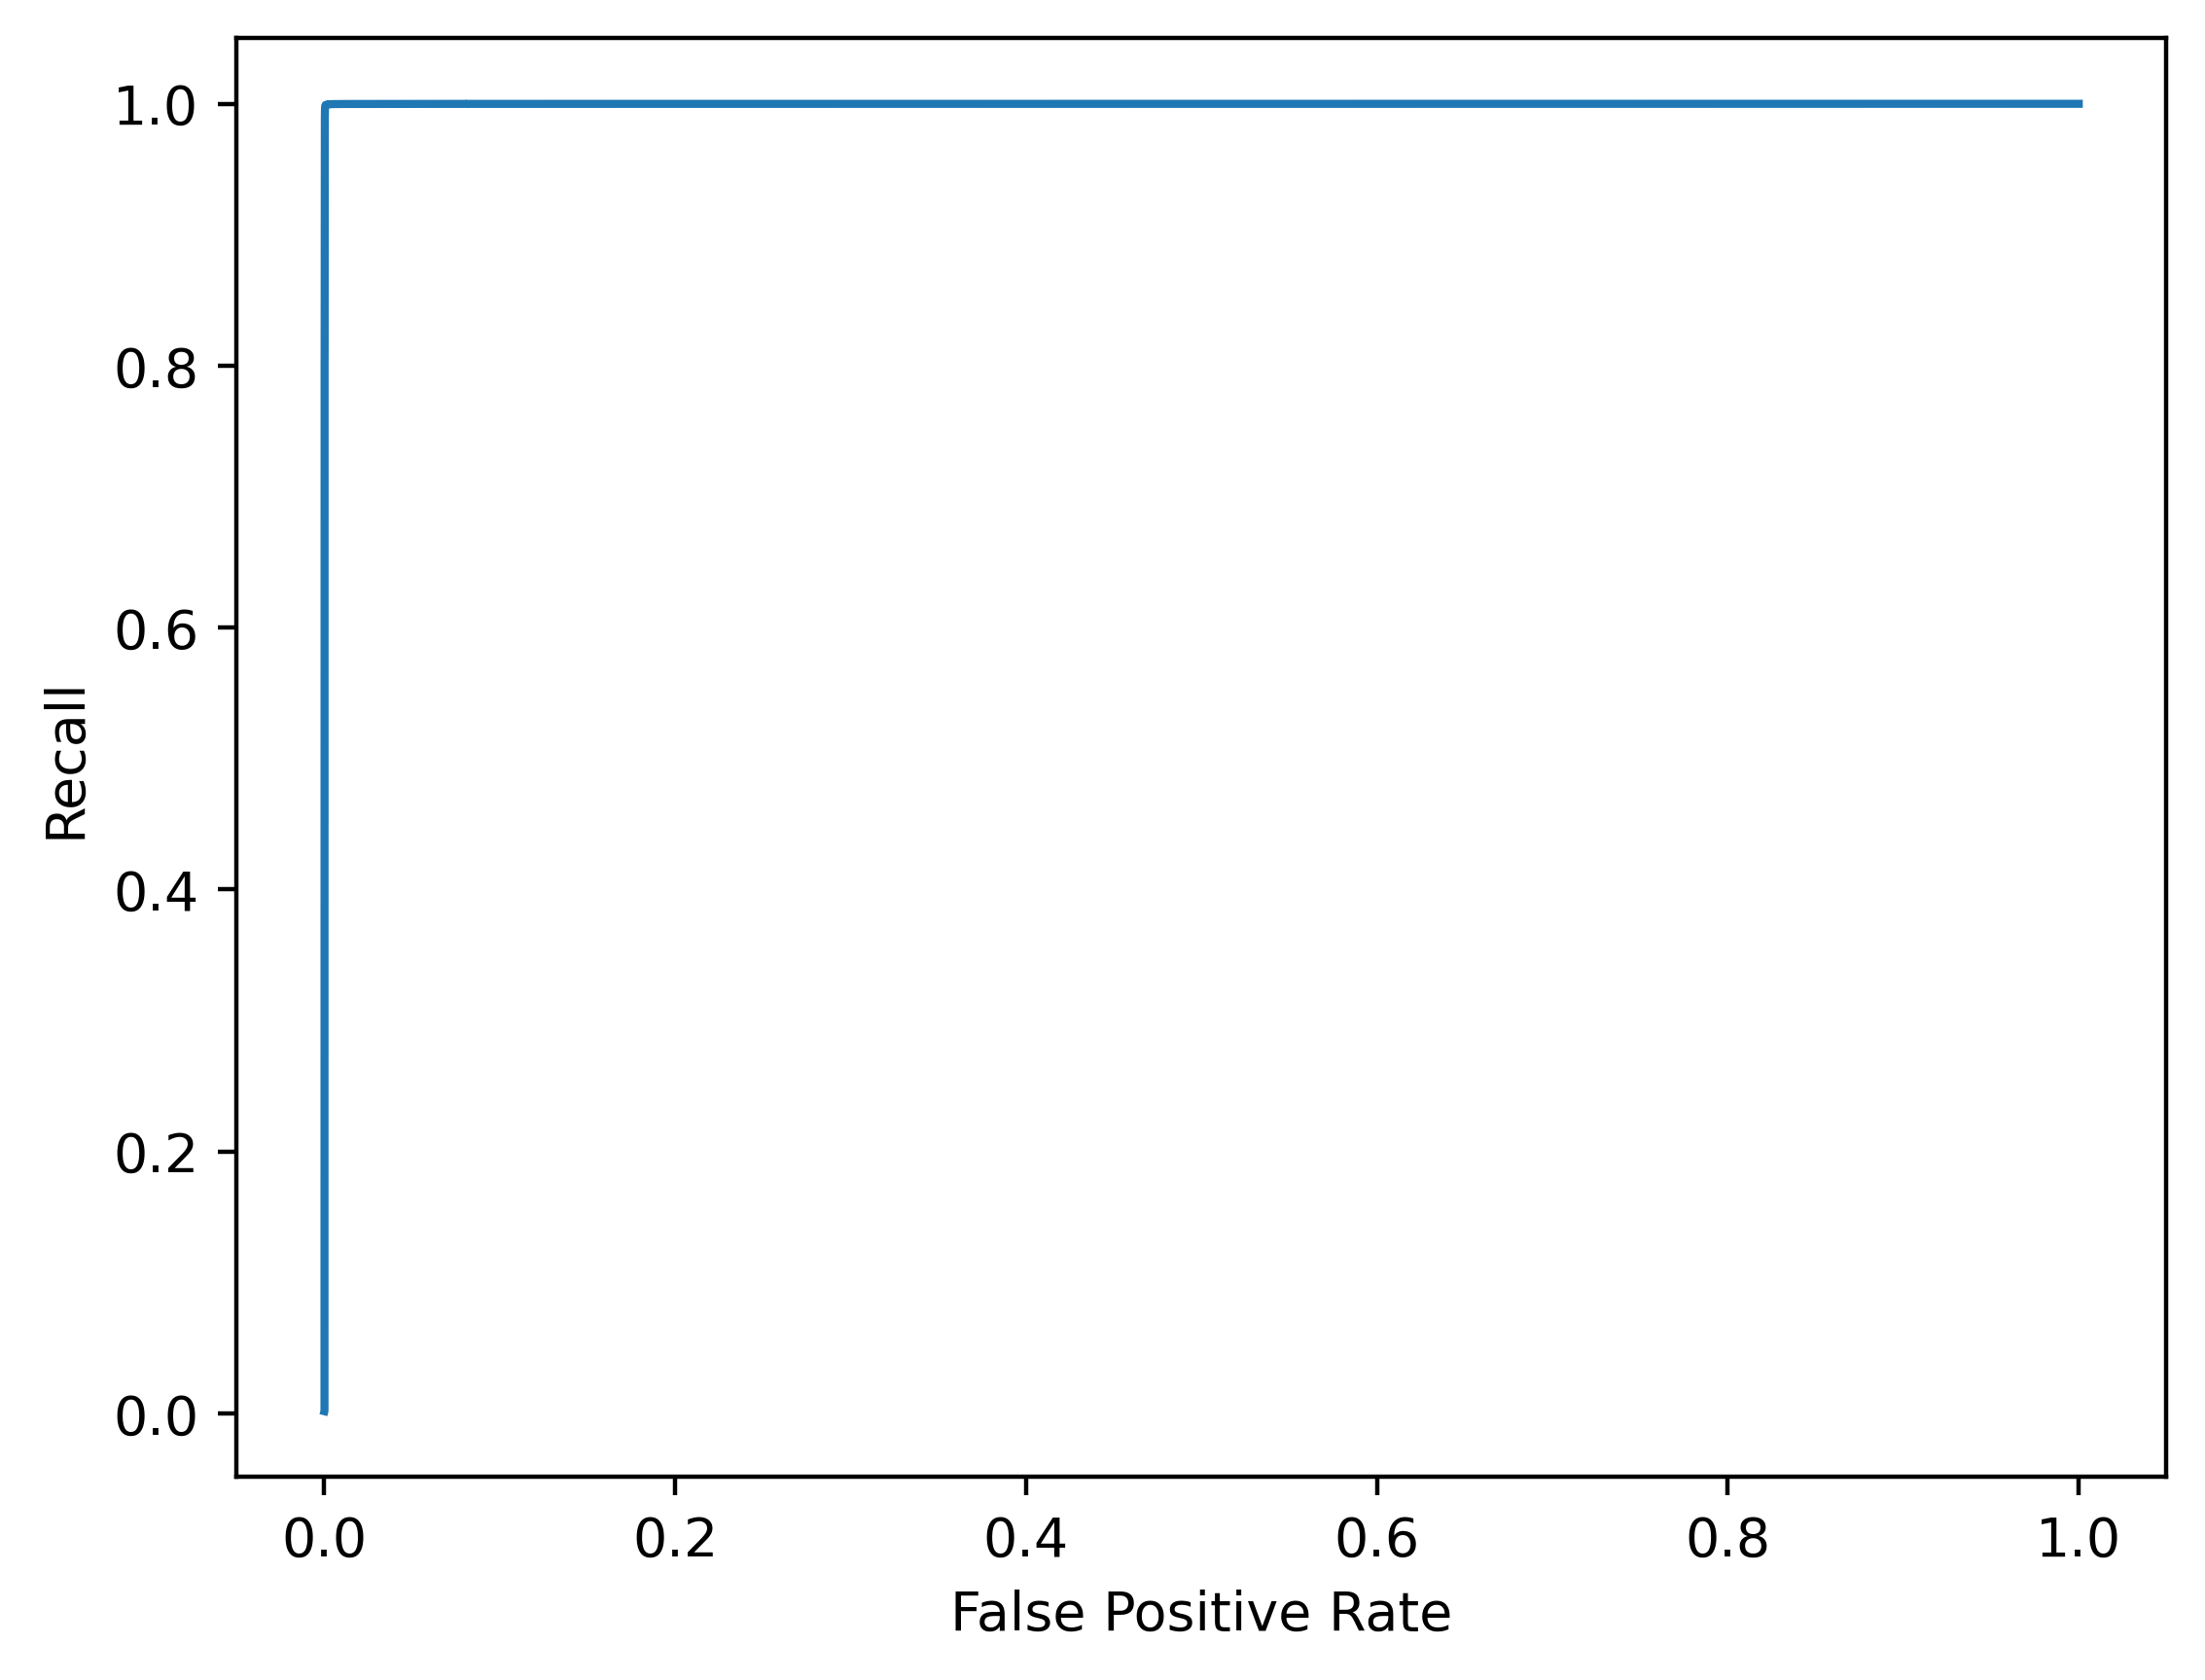

In [62]:
 
plt.figure(dpi=400)
plt.plot(
    fpr[percent(len(fpr), 0.02) : len(fpr)], tpr[percent(len(tpr), 0.02) : len(tpr)]
)
# plt.plot(fpr, tpr)
plt.ylabel("Recall")
plt.xlabel("False Positive Rate")
plt.show()


The ROC Curve shows the ratio between the Precision, or True Positive Rate (TPR), and the False Positive Rate (FPR) and has the random guessing on the bisector. This result validate our dataset to be used for Intrusion Detection. 

In [63]:
 
np.save("./fpr_xgb.npy", fpr)
np.save("./tpr_xgb.npy", tpr)


We investigate the performance of the XGBoost with a fix FPR of 0.05 

In [64]:
 
TARGET_FPR = 0.05
fpr_index = np.min(np.where(fpr >= TARGET_FPR))
fpr_value = fpr[fpr_index]
tpr_value = tpr[fpr_index]
print("TPR {} , FPR {}".format(tpr_value, fpr_value))


TPR 0.9999181634064128 , FPR 0.050007290444267015


### Compute the Precision-Recall Curve 

In [65]:
 
precision, recall, thr = metrics.precision_recall_curve(y_test, preds_proba[:, 1])


In [66]:
 
print(recall)
count = 0
for r in recall:
    if r <= 0.2:
        print(count)
        break
    count = count + 1


[1.00000000e+00 9.99980991e-01 9.99980991e-01 ... 2.80306443e-05
 2.56142094e-05 0.00000000e+00]
439710


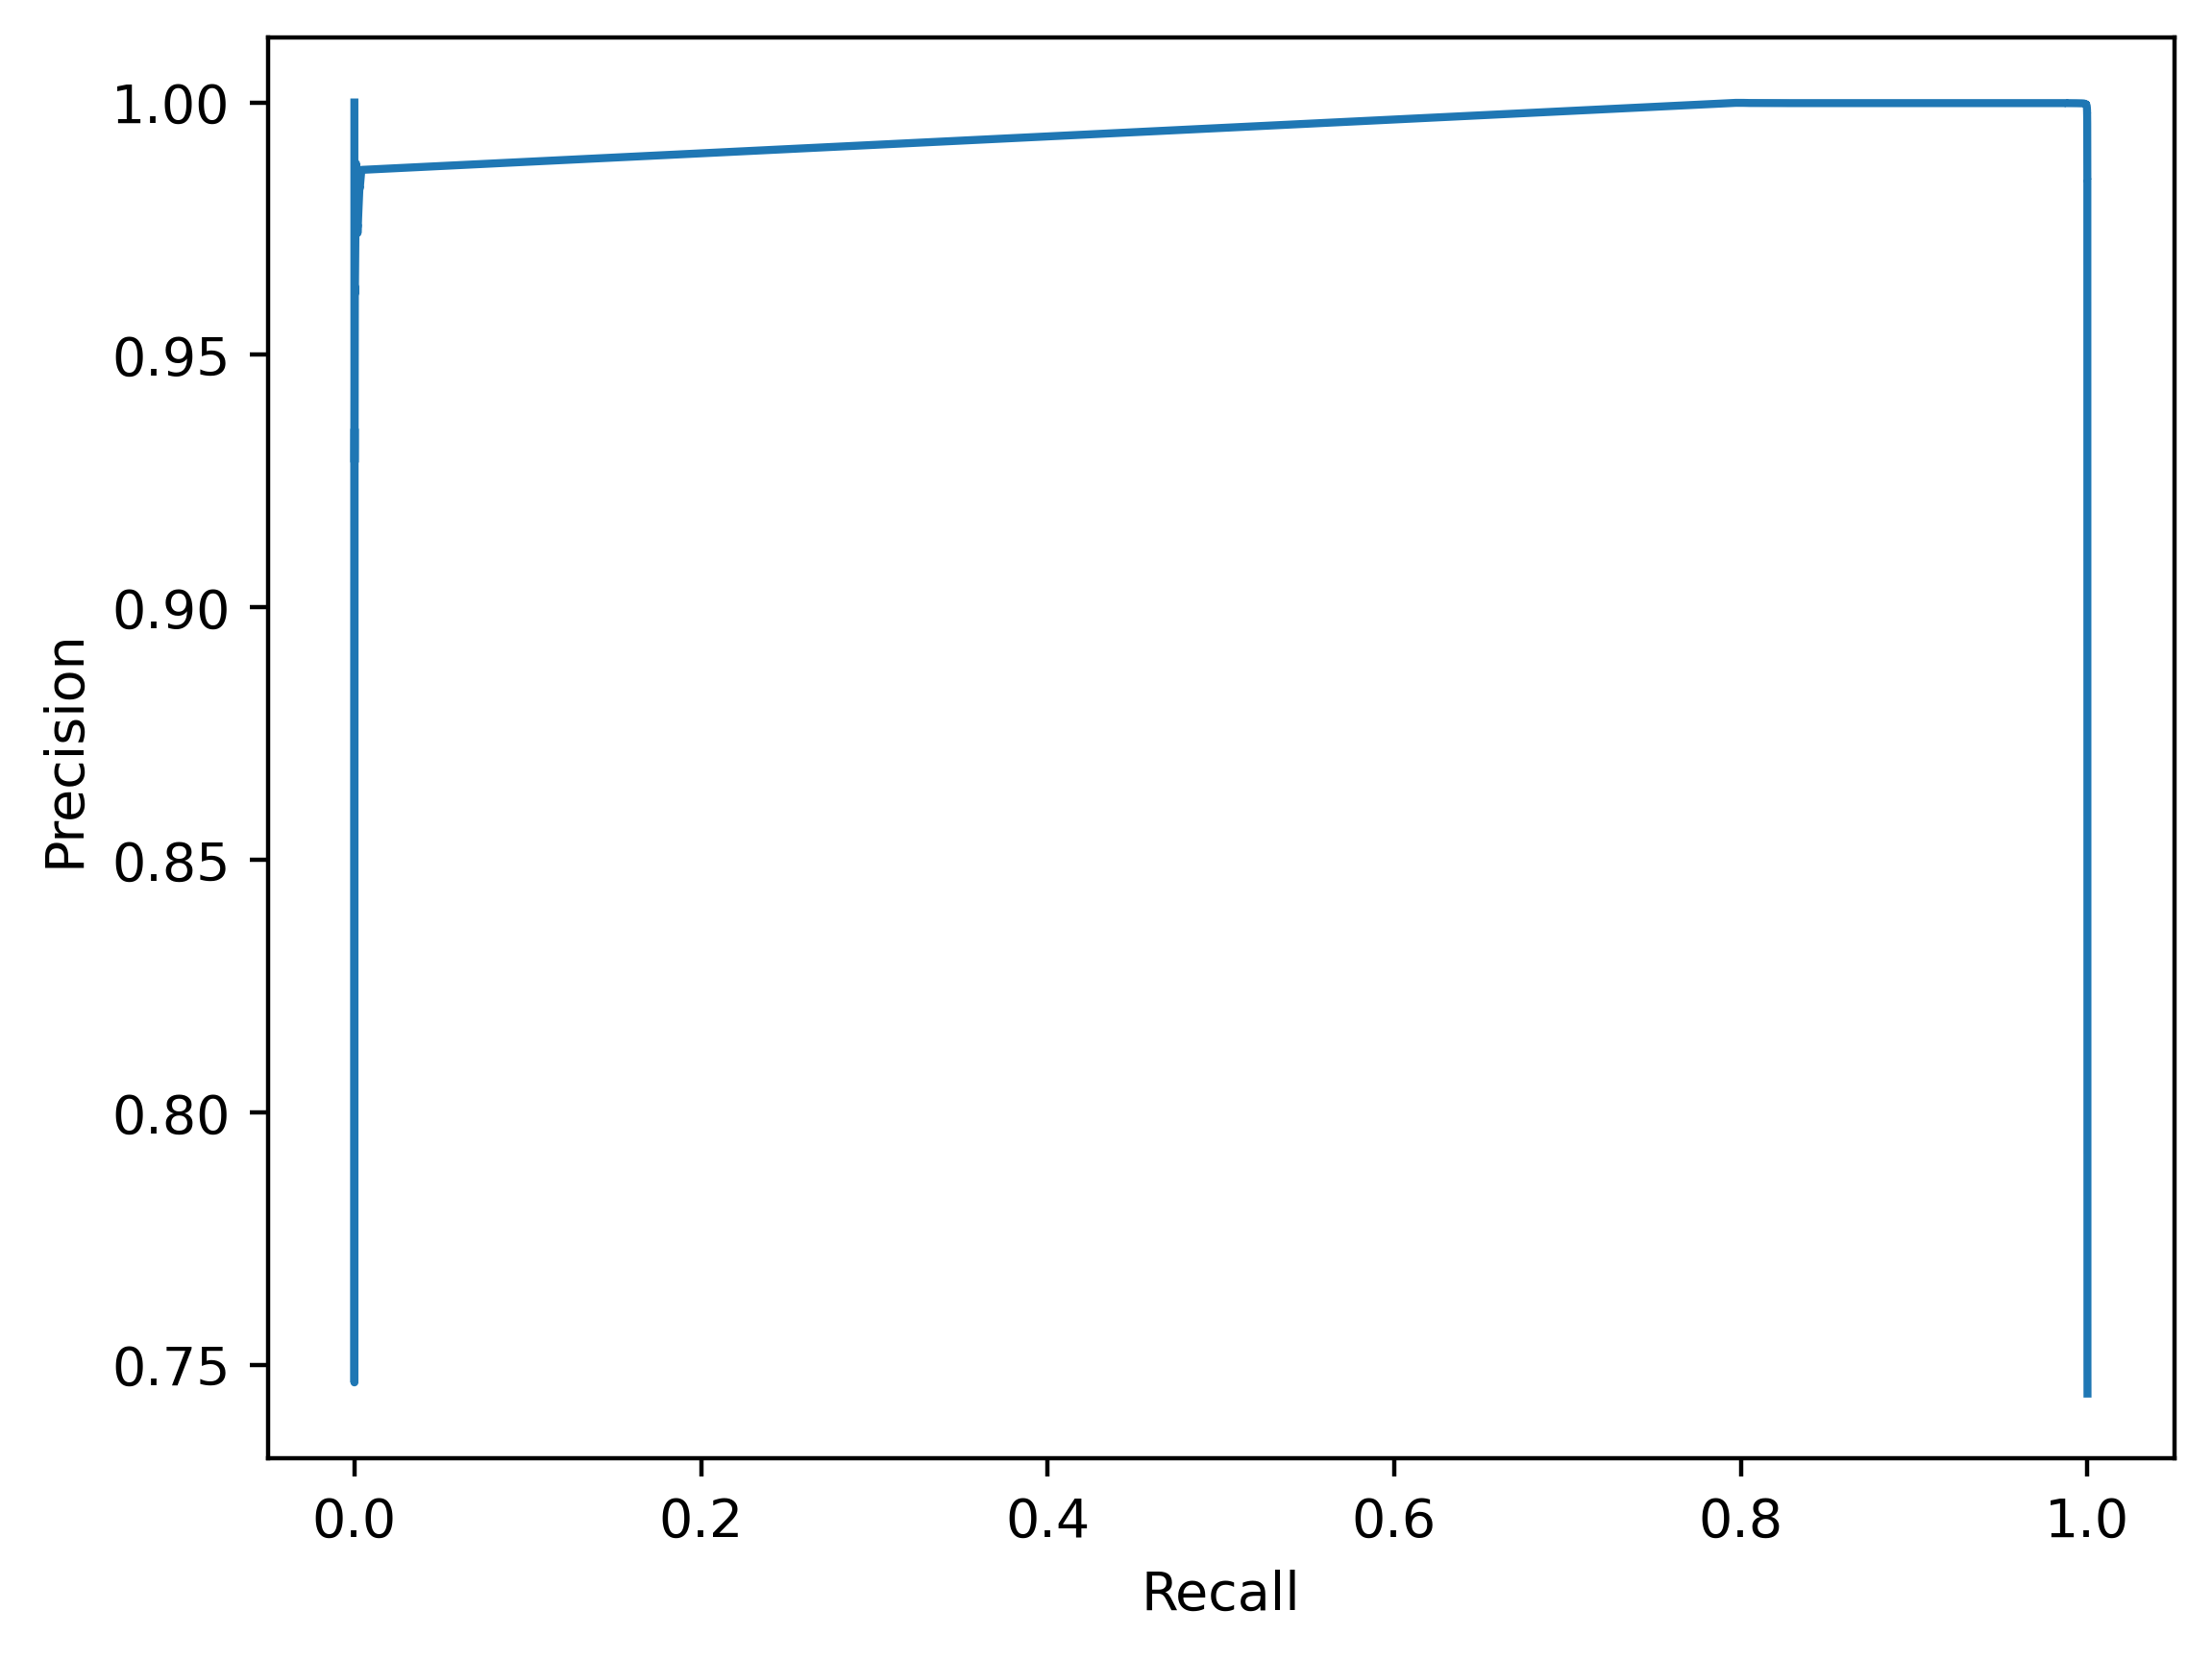

In [67]:
 
plt.figure(dpi=400)
plt.plot(recall[0:512400], precision[0:512400])
plt.ylabel("Precision")
plt.xlabel("Recall")
plt.show()


In [68]:
 
np.save("./recall_xgb.npy", recall)
np.save("./precision_xgb.npy", precision)
